## Non linear regression
### K-NN Regression: averageRating

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:

from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

In [3]:
train_df = pd.read_csv('../results/train_clean.csv', index_col=0)
test_df = pd.read_csv('../results/test_clean.csv', index_col=0)
train_df.columns


Index(['originalTitle', 'rating', 'startYear', 'runtimeMinutes', 'numVotes',
       'totalImages', 'totalCredits', 'titleType', 'canHaveEpisodes',
       'numRegions', 'countryOfOrigin', 'genres', 'ratingNum', 'numGenres',
       'criticReviewsRatio', 'awardsAndNominations', 'hasVideos',
       'moreCountriesOfOrigin'],
      dtype='object')

In [4]:
train_df['logRuntime'] = np.log(train_df['runtimeMinutes'] + 1)
test_df['logRuntime'] = np.log(test_df['runtimeMinutes'] + 1)

In [5]:
num_cols = ['startYear', 'logRuntime', 'numVotes', 'totalImages', 'totalCredits', 'numRegions', 'numGenres', 'criticReviewsRatio']
train_X = train_df[num_cols]
test_X = test_df[num_cols]

In [6]:
train_y = pd.read_csv('../data/dm1_2425_imdb_rating/train_reg.csv')['averageRating']
test_y = pd.read_csv('../data/dm1_2425_imdb_rating/test_reg.csv')['averageRating']

In [7]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', KNeighborsRegressor())
])

In [8]:
splitter = KFold(n_splits=5, shuffle=True, random_state=42)

In [9]:
%%time

ks= np.arange(1, 50, 1)
param_grid = {
    "regressor__n_neighbors": ks,
    "regressor__weights": ["uniform", "distance"],
    "regressor__metric": ["euclidean", "cityblock"]
}

grid = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    cv=splitter,
    n_jobs=-1,
    scoring="neg_mean_squared_error",
    verbose=2,
    refit=True
)

grid.fit(train_X, train_y)

Fitting 5 folds for each of 196 candidates, totalling 980 fits
[CV] END regressor__metric=euclidean, regressor__n_neighbors=1, regressor__weights=uniform; total time=   0.1s
[CV] END regressor__metric=euclidean, regressor__n_neighbors=1, regressor__weights=uniform; total time=   0.1s
[CV] END regressor__metric=euclidean, regressor__n_neighbors=1, regressor__weights=uniform; total time=   0.1s
[CV] END regressor__metric=euclidean, regressor__n_neighbors=1, regressor__weights=uniform; total time=   0.1s
[CV] END regressor__metric=euclidean, regressor__n_neighbors=1, regressor__weights=uniform; total time=   0.1s
[CV] END regressor__metric=euclidean, regressor__n_neighbors=1, regressor__weights=distance; total time=   0.1s
[CV] END regressor__metric=euclidean, regressor__n_neighbors=1, regressor__weights=distance; total time=   0.1s
[CV] END regressor__metric=euclidean, regressor__n_neighbors=1, regressor__weights=distance; total time=   0.1s
[CV] END regressor__metric=euclidean, regresso

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('regressor', KNeighborsRegressor())]),
             n_jobs=-1,
             param_grid={'regressor__metric': ['euclidean', 'cityblock'],
                         'regressor__n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]),
                         'regressor__weights': ['uniform', 'distance']},
             scoring='neg_mean_squared_error', verbose=2)

In [10]:
results = pd.DataFrame(grid.cv_results_)
results['metric and weight'] = results['param_regressor__metric'] + ' ' + results['param_regressor__weights']

Text(0, 0.5, 'Negative mean squared error')

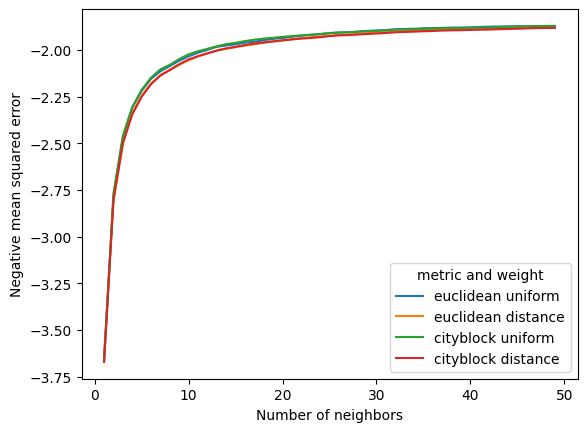

In [11]:
sns.lineplot(
    data=results,
    x='param_regressor__n_neighbors',
    y="mean_test_score",
    hue="metric and weight"
)
plt.xlabel("Number of neighbors")
plt.ylabel("Negative mean squared error")

We can see that the model is not sensible to any of the parameters. Performance is slowly getting better the more neighbors we consider and the more the model prediction is approximating the mean rating of the whole dataset.
There's no point in refining the model selection process.

In [12]:
grid.best_params_

{'regressor__metric': 'cityblock',
 'regressor__n_neighbors': np.int64(49),
 'regressor__weights': 'uniform'}

In [13]:
regressor = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', KNeighborsRegressor())
])

regressor.fit(train_X, train_y)
y_pred = regressor.predict(test_X)

The defaults are good enough for this.

In [14]:
print("Mean squared error:", mean_squared_error(y_true=test_y, y_pred=y_pred))
print("R2 score:", r2_score(y_true=test_y, y_pred=y_pred))

Mean squared error: 2.20078882803943
R2 score: -0.20119707694332356


Text(0.5, 0, 'Real average rating')

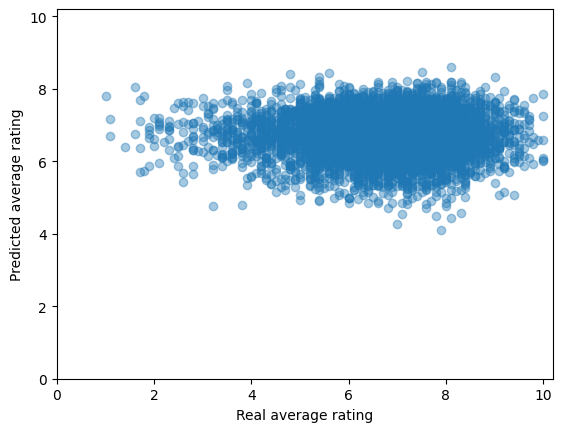

In [15]:
plt.scatter(test_y, y_pred, alpha=.4)
plt.xlim((0, 10.2))
plt.ylim((0, 10.2))
plt.ylabel("Predicted average rating")
plt.xlabel("Real average rating")

We cannot see any positive correlation between the real ratings and the predicted ratings.

We can observe that the predicted values are squeezed towards the mean rating of the entire dataset because of the strategy that the regressor uses for predicting the value (mean value of the 5 nearest neighbour). The negative R2 score means that this models performs worse than predicting the mean.

## K-NN Regression: numVotes

In [16]:
target = 'numVotes'
input_cols = num_cols.copy()
input_cols.remove(target)

In [17]:
train_X_nv, train_y_nv = train_df[input_cols], train_df[target]
test_X_nv, test_y_nv = test_df[input_cols], test_df[target]

In [18]:
%%time

ks= np.arange(1, 500, 5)
param_grid = {
    "regressor__n_neighbors": ks,
    "regressor__weights": ["uniform", "distance"],
    "regressor__metric": ["euclidean", "cityblock"]
}

grid = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    cv=splitter,
    n_jobs=-1,
    scoring="neg_mean_squared_error",
    verbose=2,
    refit=True
)

grid.fit(train_X_nv, train_y_nv)

Fitting 5 folds for each of 400 candidates, totalling 2000 fits
[CV] END regressor__metric=euclidean, regressor__n_neighbors=1, regressor__weights=uniform; total time=   0.1s
[CV] END regressor__metric=euclidean, regressor__n_neighbors=1, regressor__weights=uniform; total time=   0.1s
[CV] END regressor__metric=euclidean, regressor__n_neighbors=1, regressor__weights=uniform; total time=   0.1s
[CV] END regressor__metric=euclidean, regressor__n_neighbors=1, regressor__weights=uniform; total time=   0.1s
[CV] END regressor__metric=euclidean, regressor__n_neighbors=1, regressor__weights=uniform; total time=   0.1s
[CV] END regressor__metric=euclidean, regressor__n_neighbors=1, regressor__weights=distance; total time=   0.1s
[CV] END regressor__metric=euclidean, regressor__n_neighbors=1, regressor__weights=distance; total time=   0.1s
[CV] END regressor__metric=euclidean, regressor__n_neighbors=1, regressor__weights=distance; total time=   0.1s
[CV] END regressor__metric=euclidean, regress

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('regressor', KNeighborsRegressor())]),
             n_jobs=-1,
             param_grid={'regressor__metric': ['euclidean', 'cityblock'],
                         'regressor__n_neighbors': array([  1,   6,  11,  16,  21,  26,  31,  36,  41,  46,  51,  56,  61,
        66,  71,  76,  81,  86,  91,  96, 101, 106, 111, 116, 121, 126,
       131, 136, 141, 1...176, 181, 186, 191,
       196, 201, 206, 211, 216, 221, 226, 231, 236, 241, 246, 251, 256,
       261, 266, 271, 276, 281, 286, 291, 296, 301, 306, 311, 316, 321,
       326, 331, 336, 341, 346, 351, 356, 361, 366, 371, 376, 381, 386,
       391, 396, 401, 406, 411, 416, 421, 426, 431, 436, 441, 446, 451,
       456, 461, 466, 471, 476, 481, 486, 491, 496]),
                         'regressor__weights': ['uniform', 'distance']},
             scoring='neg_mean_squared_error', verbose=2)

In [19]:
results = pd.DataFrame(grid.cv_results_)
results['metric and weight'] = results['param_regressor__metric'] + ' ' + results['param_regressor__weights']

Text(0, 0.5, 'Negative mean squared error')

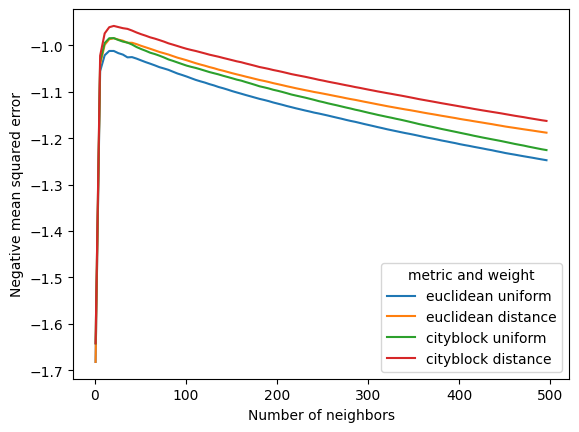

In [20]:
sns.lineplot(
    data=results,
    x='param_regressor__n_neighbors',
    y="mean_test_score",
    hue="metric and weight"
)
plt.xlabel("Number of neighbors")
plt.ylabel("Negative mean squared error")

In [21]:
grid.best_params_

{'regressor__metric': 'cityblock',
 'regressor__n_neighbors': np.int64(21),
 'regressor__weights': 'distance'}

Looks like the best k would be around 20 and the best distance measure would be cityblock and we sould weight the neighbors by distance. We refine the parameters search using values of k between 1 and 50.

We can also see that the mean squared error for this task is much lower than that for the previous task.

In [22]:
param_grid['regressor__n_neighbors'] = np.arange(1, 50)
grid_mini = GridSearchCV(pipeline,
                         param_grid=param_grid,
                         verbose=2,
                         n_jobs=-1)
grid_mini.fit(train_X_nv, train_y_nv)

Fitting 5 folds for each of 196 candidates, totalling 980 fits
[CV] END regressor__metric=euclidean, regressor__n_neighbors=1, regressor__weights=uniform; total time=   0.1s
[CV] END regressor__metric=euclidean, regressor__n_neighbors=1, regressor__weights=uniform; total time=   0.1s
[CV] END regressor__metric=euclidean, regressor__n_neighbors=1, regressor__weights=uniform; total time=   0.1s
[CV] END regressor__metric=euclidean, regressor__n_neighbors=1, regressor__weights=uniform; total time=   0.1s
[CV] END regressor__metric=euclidean, regressor__n_neighbors=1, regressor__weights=distance; total time=   0.1s
[CV] END regressor__metric=euclidean, regressor__n_neighbors=1, regressor__weights=uniform; total time=   0.1s
[CV] END regressor__metric=euclidean, regressor__n_neighbors=1, regressor__weights=distance; total time=   0.1s
[CV] END regressor__metric=euclidean, regressor__n_neighbors=1, regressor__weights=distance; total time=   0.1s
[CV] END regressor__metric=euclidean, regresso

GridSearchCV(estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('regressor', KNeighborsRegressor())]),
             n_jobs=-1,
             param_grid={'regressor__metric': ['euclidean', 'cityblock'],
                         'regressor__n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]),
                         'regressor__weights': ['uniform', 'distance']},
             verbose=2)

In [23]:
results_mini = pd.DataFrame(grid_mini.cv_results_)
results_mini['metric and weight'] = results_mini['param_regressor__metric'] + ' ' + results_mini['param_regressor__weights']

Text(0, 0.5, 'Negative mean squared error')

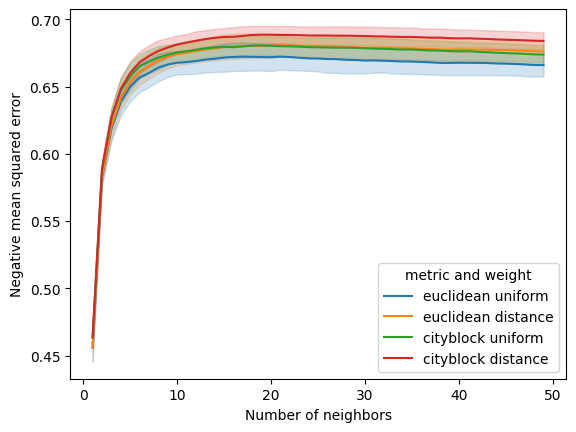

In [24]:
ax = sns.lineplot(
    data=results_mini,
    x='param_regressor__n_neighbors',
    y="mean_test_score",
    hue="metric and weight"
)

handles, labels = ax.get_legend_handles_labels()
colors = {
    label: handle.get_color()
    for label, handle in zip(labels, handles)
}

for i, (label, df) in enumerate(results_mini.groupby('metric and weight')):
    x = df['param_regressor__n_neighbors'].astype('int')
    mean_score = df['mean_test_score']
    std_score = df['std_test_score']

    ax.fill_between(
        x=x, y1=mean_score + std_score, y2=mean_score - std_score,
        alpha=.2, color=colors[label]
    )

plt.xlabel("Number of neighbors")
plt.ylabel("Negative mean squared error")

In [25]:
grid_mini.best_params_

{'regressor__metric': 'cityblock',
 'regressor__n_neighbors': np.int64(19),
 'regressor__weights': 'distance'}

In [26]:
grid_mini.best_score_

np.float64(0.6885489642488325)

In [77]:
y_pred = grid.predict(test_X_nv)

In [78]:
print("Mean squared error:", mean_squared_error(y_true=test_y_nv, y_pred=y_pred))
print("R2 score:", r2_score(y_true=test_y_nv, y_pred=y_pred))

Mean squared error: 0.9646055119317702
R2 score: 0.6869466526088873


Text(0, 0.5, 'Predicted numVotes')

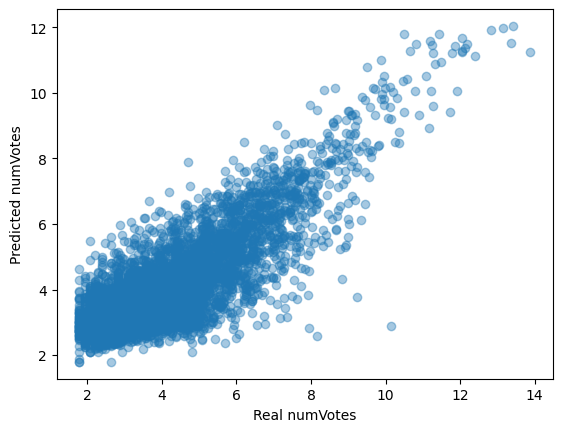

In [79]:
plt.scatter(test_y_nv, y_pred, alpha=.4)
plt.xlabel("Real numVotes")
plt.ylabel("Predicted numVotes")

In [30]:
np.corrcoef(y_pred,
            test_y_nv)

array([[1.        , 0.82903853],
       [0.82903853, 1.        ]])

We can see that the model is much better in this task. The mean squared error in much lower, we have a positive and high determination coefficient and the prediceted and real values are highly and positively correlated (Pearson 0.83), as can also be seen by the scatter plot.

## Decision Tree regressor: averageRating

We try another, less naive, approach to non linear regression.

This will be hopefully be able to also point out which input variable will be more valuable for a linear approach to regression.

The decision tree allows us to leverage also categorical features (we use the same preprocessing pipeline as for the classification). We use the original runtime values to improve interpretability.

In [31]:
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeRegressor
import ast
from collections import Counter

In [32]:
train_df['countryOfOrigin'] = train_df['countryOfOrigin'].apply(ast.literal_eval)
train_df['genres'] = train_df['genres'].apply(ast.literal_eval)
test_df['countryOfOrigin'] = test_df['countryOfOrigin'].apply(ast.literal_eval)
test_df['genres'] = test_df['genres'].apply(ast.literal_eval)

In [33]:
all_countries = [country for countries in train_df['countryOfOrigin'] for country in countries]
country_counts = Counter(all_countries) #Counter: dictionary 'country':count

top_n_countries = 40
top_countries = set([country for country, _ in country_counts.most_common(top_n_countries)])

def clean_countries(countries):
    return [c if c in top_countries else "Other" for c in countries]

train_df['country_cleaned'] = train_df['countryOfOrigin'].apply(clean_countries)
test_df['country_cleaned'] = test_df['countryOfOrigin'].apply(clean_countries)

In [34]:
countries_mbl = MultiLabelBinarizer()
genres_mbl = MultiLabelBinarizer()

train_countries = pd.DataFrame(countries_mbl.fit_transform(train_df['country_cleaned']), columns=['country_' + c for c in countries_mbl.classes_])
train_genres = pd.DataFrame(genres_mbl.fit_transform(train_df['genres']), columns=genres_mbl.classes_)
test_countries = pd.DataFrame(countries_mbl.transform(test_df['country_cleaned']), columns=['country_' + c  for c in countries_mbl.classes_])
test_genres = pd.DataFrame(genres_mbl.transform(test_df['genres']), columns=genres_mbl.classes_)

In [35]:

to_drop = ['originalTitle', 'rating', 'countryOfOrigin', 'ratingNum', 'runtimeMinutes', 'country_cleaned', 'genres']
X_train = train_df.drop(to_drop, axis=1)
X_test = test_df.drop(to_drop, axis=1)
X_train = pd.concat((X_train, train_countries, train_genres), axis=1)
X_test = pd.concat((X_test, test_countries, test_genres), axis=1)

In [36]:
regressor = Pipeline([
    ("preprocessor", ColumnTransformer(transformers=[
        ("encoder", OneHotEncoder(), ['titleType']),
        ], remainder="passthrough",
        force_int_remainder_cols=False)),
    ("tree", DecisionTreeRegressor()),
])
regressor

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('encoder', OneHotEncoder(),
                                                  ['titleType'])])),
                ('tree', DecisionTreeRegressor())])

#### Hyperparameter tuning

In [37]:
from sklearn.model_selection import RandomizedSearchCV

In [38]:
%%time

param_grid = {
    'tree__max_depth': [None] + list(np.arange(2, 20)),
    'tree__min_samples_split': [2, 5, 10, 15, 20, 30, 50, 100],
    'tree__min_samples_leaf': [1, 5, 10, 15, 20, 30, 50, 100],
}


random_search = RandomizedSearchCV(
    regressor,
    param_distributions=param_grid,
    cv=splitter,
    n_jobs=-1,
    refit=True, #refitta il miglior modello
    n_iter= 500,
    verbose=2,
    scoring='neg_mean_squared_error',
    random_state=42
)

random_search.fit(X_train, train_y)

Fitting 5 folds for each of 500 candidates, totalling 2500 fits
[CV] END tree__max_depth=5, tree__min_samples_leaf=1, tree__min_samples_split=15; total time=   0.5s
[CV] END tree__max_depth=9, tree__min_samples_leaf=15, tree__min_samples_split=30; total time=   0.5s
[CV] END tree__max_depth=9, tree__min_samples_leaf=15, tree__min_samples_split=30; total time=   0.6s
[CV] END tree__max_depth=9, tree__min_samples_leaf=15, tree__min_samples_split=30; total time=   0.5s
[CV] END tree__max_depth=9, tree__min_samples_leaf=15, tree__min_samples_split=30; total time=   0.5s
[CV] END tree__max_depth=5, tree__min_samples_leaf=1, tree__min_samples_split=15; total time=   0.6s
[CV] END tree__max_depth=5, tree__min_samples_leaf=1, tree__min_samples_split=15; total time=   0.6s
[CV] END tree__max_depth=9, tree__min_samples_leaf=15, tree__min_samples_split=30; total time=   0.7s
[CV] END tree__max_depth=5, tree__min_samples_leaf=1, tree__min_samples_split=15; total time=   0.4s
[CV] END tree__max_dep

RandomizedSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(force_int_remainder_cols=False,
                                                                remainder='passthrough',
                                                                transformers=[('encoder',
                                                                               OneHotEncoder(),
                                                                               ['titleType'])])),
                                             ('tree',
                                              DecisionTreeRegressor())]),
                   n_iter=500, n_jobs=-1,
                   param_distributions={'tree__max_depth': [None, np.int...
                                                            np.int64(5),
                                                            np.int64(6),
                                                            np.int64(7),
                                                            np.int64(8),
                                                            np.int64(9),
                                                            np.int64(10),
                                                            np.int64(11),
                                                            np.int64(12),
                                                            np.int64(13),
                                                            np.int64(14),
                                                            np.int64(15),
                                                            np.int64(16),
                                                            np.int64(17),
                                                            np.int64(18),
                                                            np.int64(19)],
                                        'tree__min_samples_leaf': [1, 5, 10, 15,
                                                                   20, 30, 50,
                                                                   100],
                                        'tree__min_samples_split': [2, 5, 10,
                                                                    15, 20, 30,
                                                                    50, 100]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=2)

In [39]:
from sklearn.tree import plot_tree

In [40]:
random_search.best_params_

{'tree__min_samples_split': 2,
 'tree__min_samples_leaf': 100,
 'tree__max_depth': np.int64(2)}

There's no need for to prune the tree, because it is a very simple one.
The performance in validation is somewhat better that the performance of the previous regressor, but it isn't in any way good: as a matter of fact, the mean squared error in validation is greater than the variance of the target variable.

In [41]:
random_search.best_score_

np.float64(-1.8407504657238838)

In [42]:
train_y.var()

np.float64(1.835470277465295)

In [43]:
model = random_search.best_estimator_
y_pred = model.predict(X_test)

Text(0, 0.5, 'Predicted rating')

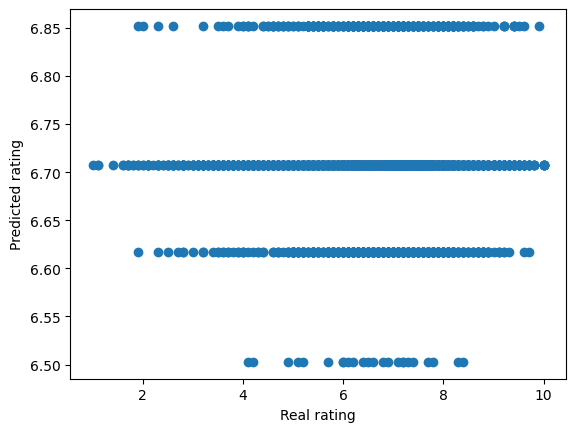

In [44]:
plt.scatter(test_y, y_pred)
plt.xlabel("Real rating")
plt.ylabel("Predicted rating")

In [45]:
print("Mean squared error:", mean_squared_error(y_true=test_y, y_pred=y_pred))
print("R2 score:", r2_score(y_true=test_y, y_pred=y_pred))

Mean squared error: 1.8340927575636186
R2 score: -0.001053272880784828


R2 score is negative also for this model.

In [46]:
feature_names = model[:-1].get_feature_names_out()
feature_names = [name.split('__')[1] for name in feature_names]

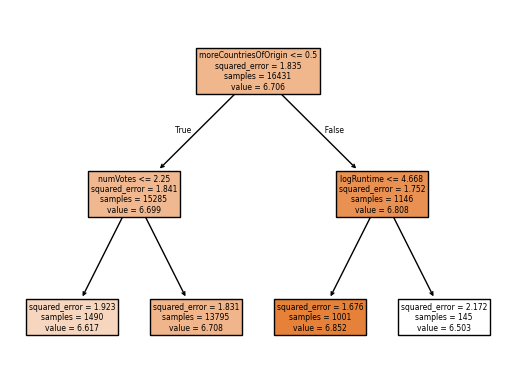

In [47]:
plot_tree(model['tree'], filled=True, feature_names=feature_names)
plt.show()

### Decision Tree Regressor: numVotes

We can use the same pipeline as before, we only need to remove numVotes from the input and change the target variable.

In [48]:
X_train.drop('numVotes', axis=1, inplace=True)
X_test.drop('numVotes', axis=1, inplace=True)

In [51]:
%%time

param_grid = {
    'tree__max_depth': [None] + list(np.arange(2, 20)),
    'tree__min_samples_split': [2, 5, 10, 15, 20, 30, 50, 100],
    'tree__min_samples_leaf': [1, 5, 10, 15, 20, 30, 50, 100],
}


random_search = RandomizedSearchCV(
    regressor,
    param_distributions=param_grid,
    cv=splitter,
    n_jobs=-1,
    refit=True, #refitta il miglior modello
    n_iter= 500,
    verbose=2,
    scoring='neg_mean_squared_error',
    random_state=42
)

random_search.fit(X_train, train_y_nv)

Fitting 5 folds for each of 500 candidates, totalling 2500 fits
[CV] END tree__max_depth=9, tree__min_samples_leaf=15, tree__min_samples_split=30; total time=   0.5s
[CV] END tree__max_depth=9, tree__min_samples_leaf=15, tree__min_samples_split=30; total time=   0.5s
[CV] END tree__max_depth=5, tree__min_samples_leaf=1, tree__min_samples_split=15; total time=   0.5s
[CV] END tree__max_depth=9, tree__min_samples_leaf=15, tree__min_samples_split=30; total time=   0.6s
[CV] END tree__max_depth=9, tree__min_samples_leaf=15, tree__min_samples_split=30; total time=   0.6s
[CV] END tree__max_depth=5, tree__min_samples_leaf=1, tree__min_samples_split=15; total time=   0.6s
[CV] END tree__max_depth=9, tree__min_samples_leaf=15, tree__min_samples_split=30; total time=   0.6s
[CV] END tree__max_depth=5, tree__min_samples_leaf=1, tree__min_samples_split=15; total time=   0.7s
[CV] END tree__max_depth=5, tree__min_samples_leaf=1, tree__min_samples_split=15; total time=   0.3s
[CV] END tree__max_dep

RandomizedSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(force_int_remainder_cols=False,
                                                                remainder='passthrough',
                                                                transformers=[('encoder',
                                                                               OneHotEncoder(),
                                                                               ['titleType'])])),
                                             ('tree',
                                              DecisionTreeRegressor())]),
                   n_iter=500, n_jobs=-1,
                   param_distributions={'tree__max_depth': [None, np.int...
                                                            np.int64(5),
                                                            np.int64(6),
                                                            np.int64(7),
                                                            np.int64(8),
                                                            np.int64(9),
                                                            np.int64(10),
                                                            np.int64(11),
                                                            np.int64(12),
                                                            np.int64(13),
                                                            np.int64(14),
                                                            np.int64(15),
                                                            np.int64(16),
                                                            np.int64(17),
                                                            np.int64(18),
                                                            np.int64(19)],
                                        'tree__min_samples_leaf': [1, 5, 10, 15,
                                                                   20, 30, 50,
                                                                   100],
                                        'tree__min_samples_split': [2, 5, 10,
                                                                    15, 20, 30,
                                                                    50, 100]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=2)

In [52]:
random_search.best_score_

np.float64(-0.9732463060199953)

In [81]:
random_search.best_params_

{'tree__min_samples_split': 50,
 'tree__min_samples_leaf': 15,
 'tree__max_depth': np.int64(11)}

In [53]:
model = random_search.best_estimator_
y_pred = model.predict(X_test)

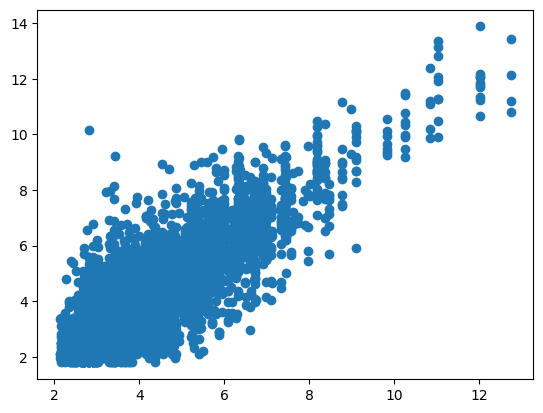

In [54]:
plt.scatter(y_pred, test_y_nv)

In [55]:
print("Mean squared error:", mean_squared_error(y_true=test_y_nv, y_pred=y_pred))
print("R2 score:", r2_score(y_true=test_y_nv, y_pred=y_pred))

Mean squared error: 1.0033512273476979
R2 score: 0.6743721070998859


In [56]:
feature_names.remove('numVotes')

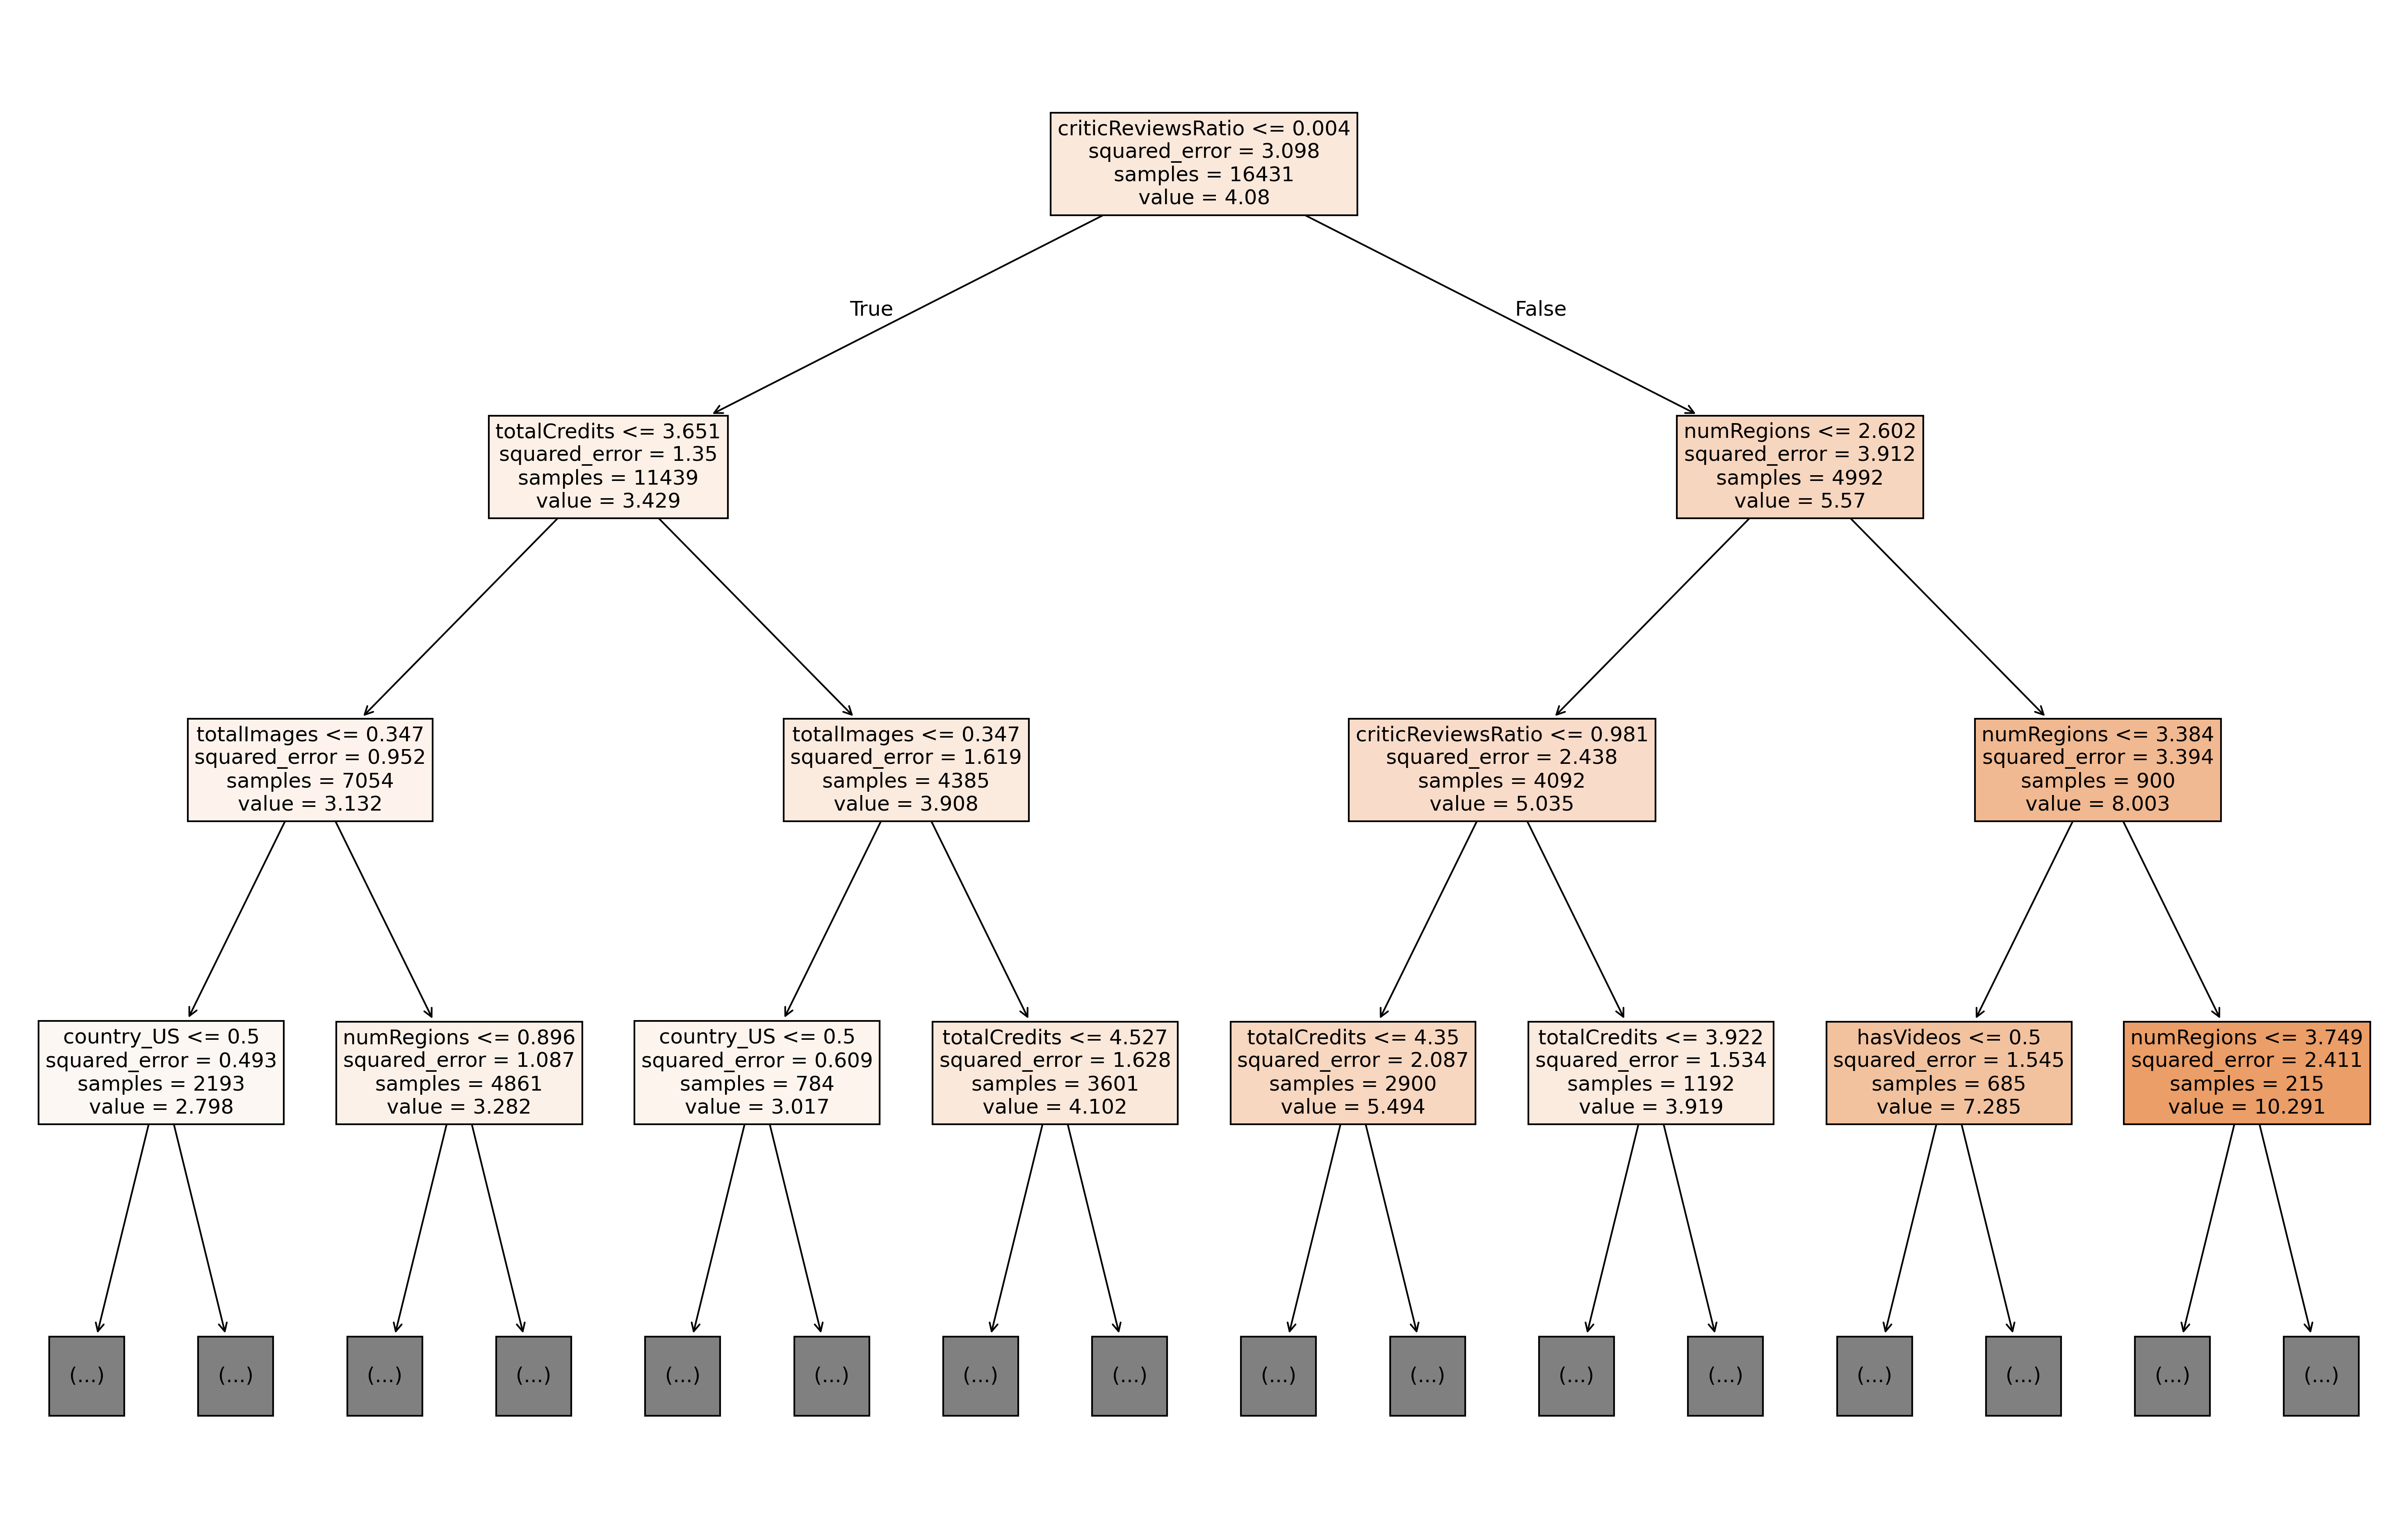

In [57]:
plt.figure(figsize=(25, 16), dpi=300)
plot_tree(model['tree'], filled=True, feature_names=feature_names, max_depth=3, fontsize=12)
plt.show()

In [58]:
feat_importance = pd.DataFrame(model['tree'].feature_importances_, index=feature_names, columns=["importance"])
feat_importance.sort_values('importance', ascending=False).head(10)

,importance
criticReviewsRatio,0.484027
numRegions,0.247768
totalCredits,0.111535
totalImages,0.060031
startYear,0.021910
logRuntime,0.012734
country_US,0.011936
titleType_tvEpisode,0.009110
hasVideos,0.007594
numGenres,0.006915


The performance of the decision tree regressor is worse than that of the nearest neighbor regressor.
However, we can use the feature importance from this model to determine which features would be most useful for a linear model for regression.

## Linear Regression

In [59]:
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

In [60]:
numeric_df = train_X.copy()
numeric_df['meanRating'] = train_y

<Axes: >

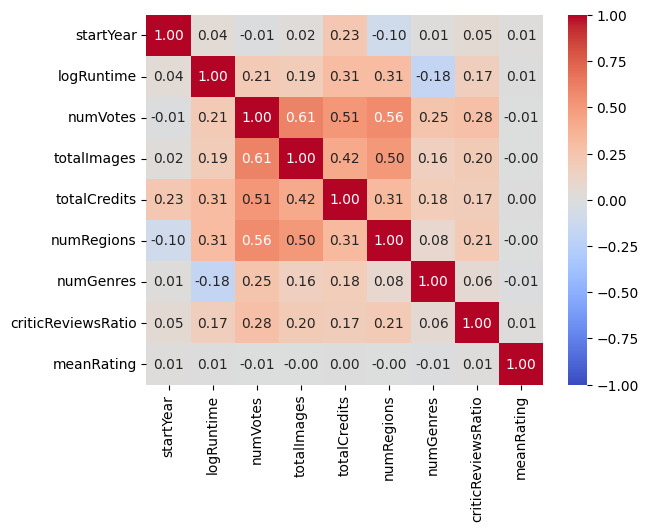

In [61]:
sns.heatmap(numeric_df.corr(), cmap="coolwarm", center=0, vmin=-1, vmax=1, annot=True, fmt=".2f")

### numVotes

In [62]:
features = ['totalImages', 'numRegions', 'totalCredits']
features = num_cols.copy()
features.remove('numVotes')
X_train = train_df[features]
X_test = test_df[features]

In [63]:
linear_regressor = Pipeline([
    ('scaler', StandardScaler()),
    ('linear_model', LinearRegression())
])

In [64]:
cross_val_score(linear_regressor, X_train, train_y_nv, cv=splitter).mean()

np.float64(0.5474604134501593)

In [65]:
ridge_regressor = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', RidgeCV(alphas=[1e-3, 1e-2, 1e-1, 1, 10, 100]))
])

In [66]:
ridge_regressor.fit(X_train, train_y_nv)
ridge_regressor.score(X_train, train_y_nv)

0.5480170376030926

In [67]:
ridge_regressor['ridge'].alpha_

np.float64(10.0)

Scores in validation:
- with features criticReviewsRatio, numRegions, totalCredits (top features for decision tree): ordinary least squares 0.459, Ridge (alpha=10) 0.459;
- with features totalImages, numRegions, totalCredits (top features for decision tree): ordinary least squares 0.518, Ridge (alpha=10) 0.519;
- with all numeric features: ordinary least squares 0.547, Ridge (alpha=10) 0.548;

This also illustrates how the problem of collinearity is manifested in decision trees: since totalImages is highly correlated with criticReviewsRatio, which was used for the first split, its importance is underestimated by the model.

So we test only the best linear model.

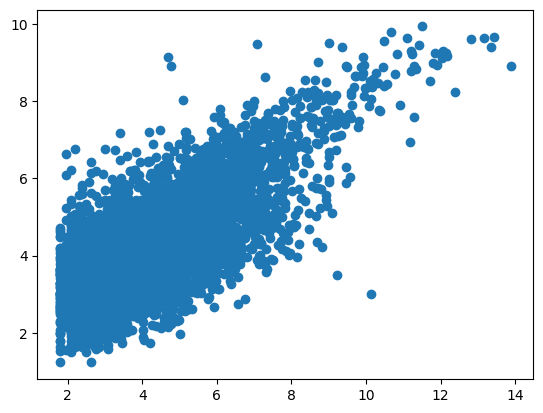

In [68]:
y_pred = ridge_regressor.predict(X_test)
plt.scatter(test_y_nv, y_pred)

In [69]:
print("R2 score", r2_score(y_pred=y_pred, y_true=test_y_nv))
print("Mean squared error", mean_squared_error(y_pred=y_pred, y_true=test_y_nv))

R2 score 0.549049860112898
Mean squared error 1.3895043581758884


In [70]:
for feat, coef in zip(features, ridge_regressor['ridge'].coef_):
    print(feat, coef)

startYear -0.09796823209676084
logRuntime -0.0330752421299102
totalImages 0.546854130374968
totalCredits 0.4753959192573869
numRegions 0.5102207240159772
numGenres 0.21187179559045077
criticReviewsRatio 0.19118644221082942


The performance is however much worse than that of the non linear models.

### Mean rating

We can see that no numeric feature is significantly correlated with the mean rating, so we try with the two numeric features used by the decision tree.

In [71]:
features = ['numVotes', 'runtimeMinutes']
X_train = train_df[features]
X_test = train_df[features]

In [72]:
cross_val_score(linear_regressor, X_train, train_y, cv=splitter).mean()

np.float64(-0.0006531835400323205)

And with all numeric features for good measure.

In [73]:
X_train = train_df[num_cols]
X_test = test_df[num_cols]

In [74]:
cross_val_score(linear_regressor, X_train, train_y, cv=splitter).mean()

np.float64(-0.0011552974237276636)

There's no amount of regularization that can make this a good model.

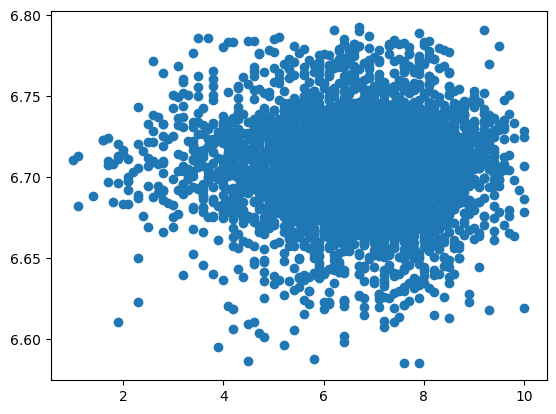

In [75]:
linear_regressor.fit(X_train, train_y)
y_pred = linear_regressor.predict(X_test)
plt.scatter(test_y, y_pred)

In [76]:
print("R2 score", r2_score(y_pred=y_pred, y_true=test_y))
print("Mean squared error", mean_squared_error(y_pred=y_pred, y_true=test_y))

R2 score -0.00016968929561755886
Mean squared error 1.8324738884203273
